In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import io

# Loading the data set
csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

df = pd.read_csv(io.StringIO(csv_data))

# Shape and data types
print("--- First 5 Rows ---")
print(df.head())

# Shape and data types
print(f"\nShape: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)

# Summary statistics
print("\n--- Summary Statistics ---")
print(df.describe())

# Pass/Fail counts
print("\n--- Pass vs Fail Count ---")
print(df['passed'].value_counts())

# Average score per subject (Passing vs Failing)
subject_cols = ['math', 'science', 'english', 'history', 'pe']
print("\n--- Average Scores (Passing Students) ---")
print(df[df['passed'] == 1][subject_cols].mean())
print("\n--- Average Scores (Failing Students) ---")
print(df[df['passed'] == 0][subject_cols].mean())

# Student with highest overall average
df['overall_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['overall_avg'].idxmax()]
print(f"\nStudent with highest average: {top_student['name']} ({top_student['overall_avg']:.2f})")

--- First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

--- Data Types ---
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistics ---
            math    s

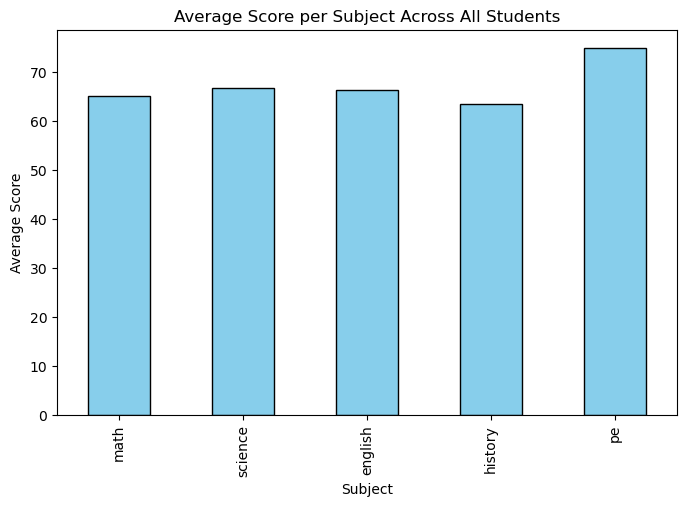

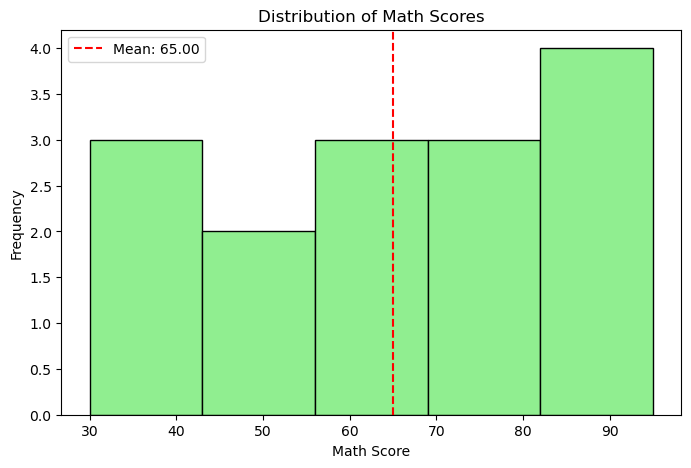

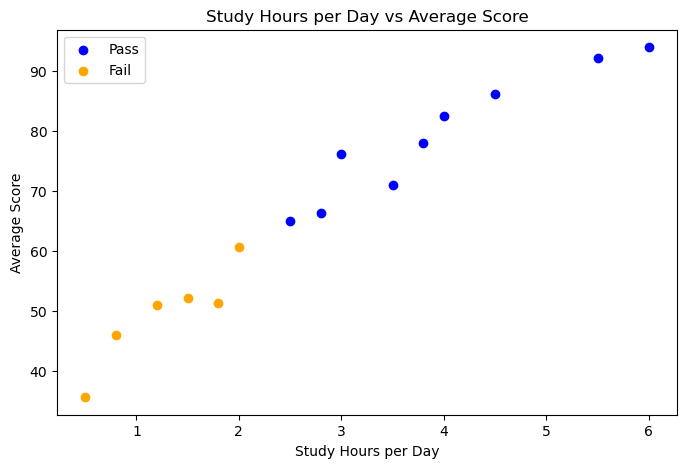

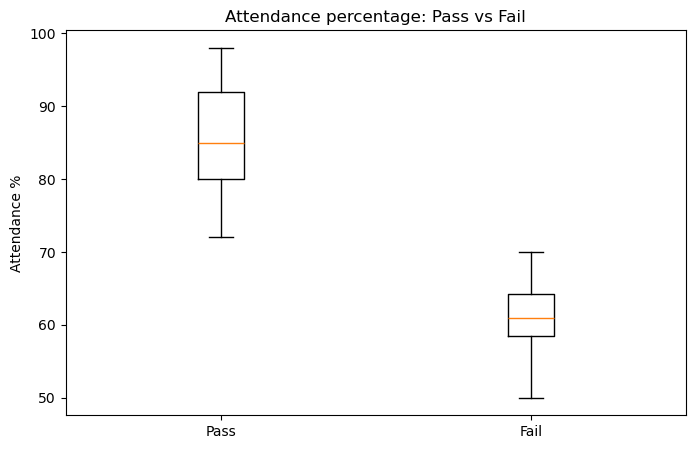

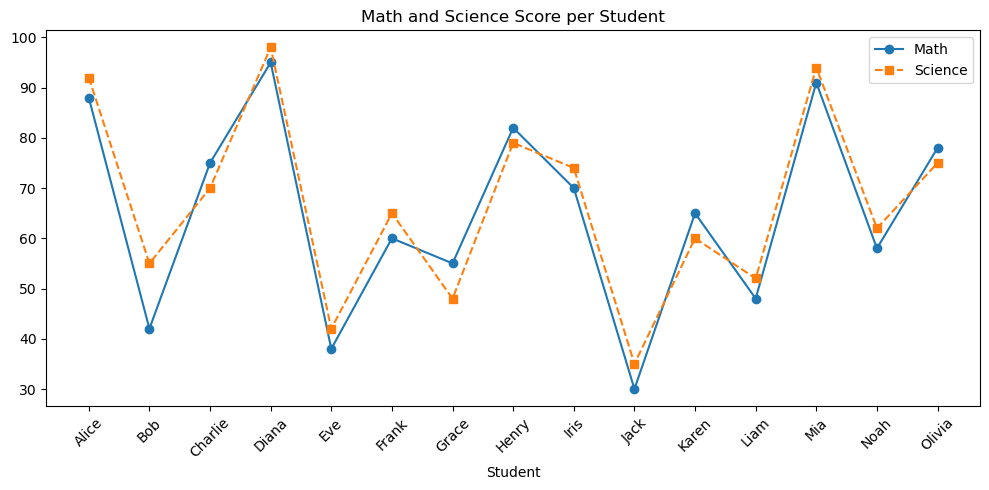

In [3]:
# Adding the new column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# Generating plots and saving them in the folder

# 1 Bar chart for average per subject
plt.figure(figsize=(8, 5))
df[subject_cols].mean().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Score per Subject Across All Students')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.savefig('plot1_bar.png')
plt.show()

# 2 Histogram showing math distribution
plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
math_mean = df['math'].mean()
plt.axvline(math_mean, color='red', linestyle='dashed', label=f'Mean: {math_mean:.2f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('plot2_hist.png')
plt.show()

# 3 Scatter plot for study hours vs average scores
plt.figure(figsize=(8, 5))
plt.scatter(df[df['passed'] == 1]['study_hours_per_day'], df[df['passed'] == 1]['avg_score'], color='blue', label='Pass')
plt.scatter(df[df['passed'] == 0]['study_hours_per_day'], df[df['passed'] == 0]['avg_score'], color='orange', label='Fail')
plt.title('Study Hours per Day vs Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()
plt.savefig('plot3_scatter.png')
plt.show()  # ← added

# 4 Box plot for attendance
plt.figure(figsize=(8, 5))
pass_attn = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attn = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.boxplot([pass_attn, fail_attn], labels=['Pass', 'Fail'])  # ← tick_labels → labels
plt.title('Attendance percentage: Pass vs Fail')              # ← typo fixed
plt.ylabel('Attendance %')
plt.savefig('plot4_box.png')
plt.show()

# 5 Line plot for Maths vs Science
plt.figure(figsize=(10, 5))
plt.plot(df['name'], df['math'], marker='o', label='Math', linestyle='-')
plt.plot(df['name'], df['science'], marker='s', label='Science', linestyle='--')
plt.title('Math and Science Score per Student')
plt.xlabel('Student')  # ← added missing x-axis label
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('plot5_line.png')
plt.show()

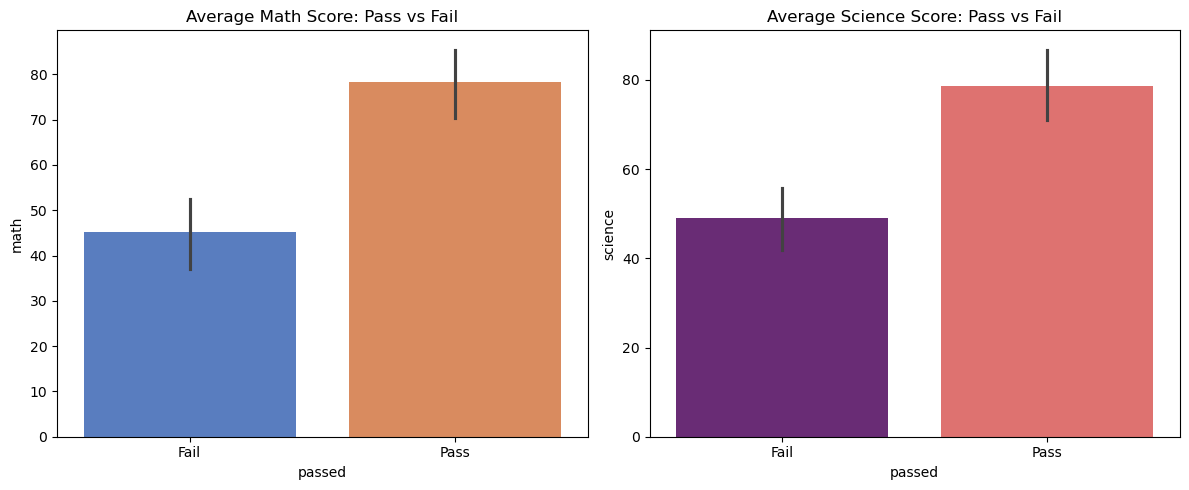

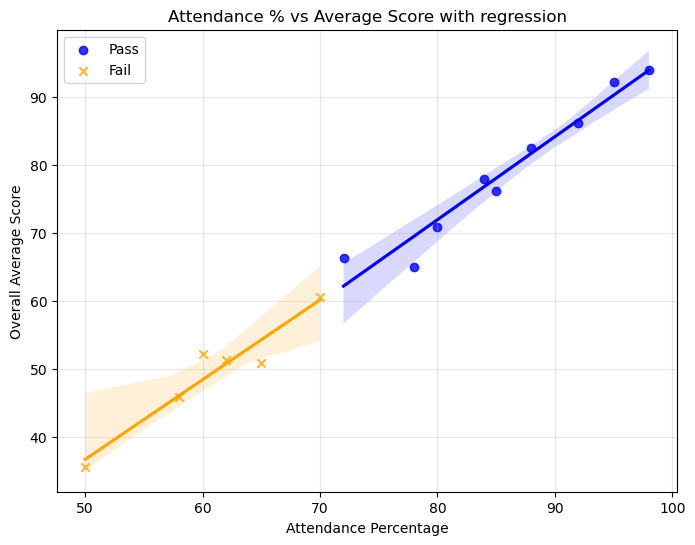

In [11]:
# Task 3: Data visualization with seaborn

import micropip
await micropip.install('seaborn')
#Task 3: Data visualization with seaborn
import matplotlib.pyplot as plt
import seaborn as sns
#1 Subplots for Math and Science averages splitting them by pass and fail 
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

#Math bar plot
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='muted', hue='passed', legend=False)
ax1.set_title('Average Math Score: Pass vs Fail')
ax1.set_xticks([0,1])
ax1.set_xticklabels(['Fail', 'Pass'])

#Science bar plot
sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='magma', hue='passed', legend=False)
ax2.set_title('Average Science Score: Pass vs Fail')
ax2.set_xticks([0,1])
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig('plot6_seaborn_bars.png')
plt.show()

#Scatter plot with regression lines
plt.figure(figsize=(8,6))
#Plotting regression lines for each group separately
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score',
            label='Pass', color='blue', marker='o')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score',
                    label='Fail', color='orange', marker='x')
plt.title('Attendance % vs Average Score with regression')
plt.xlabel('Attendance Percentage')
plt.ylabel('Overall Average Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plot7_seaborn_scatter_reg.png')
plt.show()

### Comparison comment: While creating the plots,Seaborn was quite efficient in creating same or even better plots in some case with only few lines of code which makes it faster as well.
# The reason for Seaborn to be more efficient in comparison to Matplotlib as it does aggregation automatically as well as created professional looking regression lines and color palettes for grouped data.

Training Accuracy: 100.00%
Testing Accuracy: 100.00%

--- Detailed Test results ---
Student: Jack     | Actual: 0 | Predicted: 0 | correct
Student: Liam     | Actual: 0 | Predicted: 0 | correct
Student: Alice    | Actual: 1 | Predicted: 1 | correct

Feature Coeffecients (Sorted by Importance):
               Feature  Coefficient
2              english     0.812513
5       attendance_pct     0.521876
6  study_hours_per_day     0.484433
4                   pe     0.474974
0                 math     0.437944
1              science     0.323010
3              history     0.262929


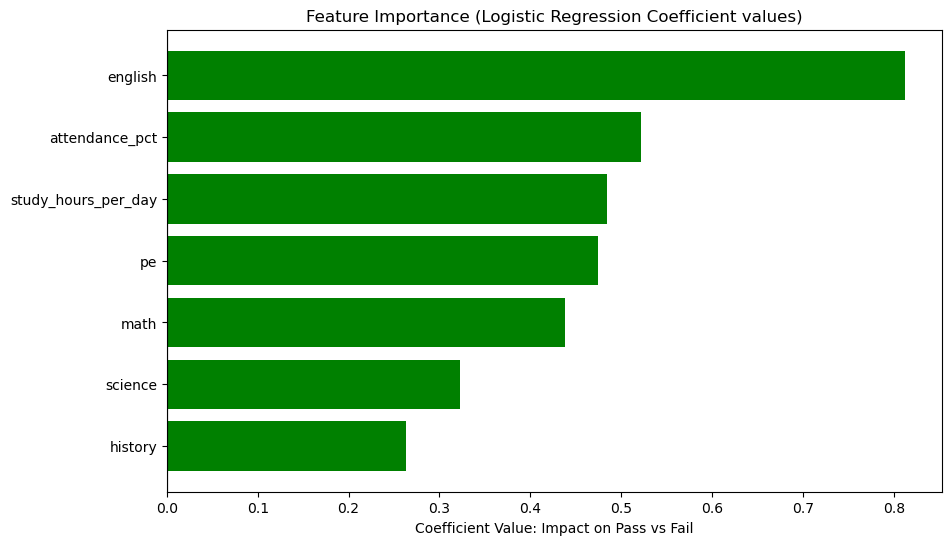


Prediction for new student: Pass
Confidence: Fail (9.20%), Pass (90.80%)


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#Step 1: Preparing data
features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[features]
y = df['passed']

#Split 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

#Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Step 2: Training the model 
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc:.2%}")

#Step 3: Evaluating the model
y_pred = model.predict(X_test_scaled)
test_acc = model.score(X_test_scaled, y_test)
print(f"Testing Accuracy: {test_acc:.2%}\n")

#Student-by-student detailed report
print("--- Detailed Test results ---")
test_indices = X_test.index
test_names = df.loc[test_indices, 'name'].values

for name, actual, pred in zip(test_names, y_test, y_pred):
    status="correct" if actual == pred else "incorrect" 
    print(f"Student: {name:8} | Actual: {actual} | Predicted: {pred} | {status}")

#Step 4: Feature importance 
coeffs = model.coef_[0]
#Creaing data frame to help in sorting and plotting
importance_df = pd.DataFrame({'Feature': features, 'Coefficient': coeffs})
importance_df['Abs_Coeff'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coeff', ascending=False)

print("\nFeature Coeffecients (Sorted by Importance):")
print(importance_df[['Feature', 'Coefficient']])

#Horizontal Bar Chart for Importance
plt.figure(figsize=(10,6))
#Green for positive impact and red for negative impact
colors = ['green' if c > 0 else 'red' for c in importance_df['Coefficient']]

plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8) 
plt.title('Feature Importance (Logistic Regression Coefficient values)')
plt.xlabel('Coefficient Value: Impact on Pass vs Fail')
plt.gca().invert_yaxis()
plt.show()

#Step 5: Predicting for a new student for the bonus question
new_student_data = [[75,70,68,65,80,82,3.2]] # In the same format above math, science, english, history, pe, attendance_pct, study_hours_per_day
new_student_df = pd.DataFrame(new_student_data, columns=features) # Wrapping it in Df(Data Frame) so it has the same column names as the training data, features is the list defined aboved
new_student_scaled = scaler.transform(new_student_df)

prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"
print(f"\nPrediction for new student: {result}")
print(f"Confidence: Fail ({probability[0]:.2%}), Pass ({probability[1]:.2%})")